# Shell ladders: where to put them, and what a good one is worth

The rare-event estimator does not fly one encounter to the end. It moves a cloud of particles down
through a sequence of **shells** — separations that get smaller — and keeps only the particles
that reach each one. The estimate is the product of the fractions that survive.

That sequence is the **ladder**. It starts where encounters usually end up and it finishes at
`rpz`. This notebook shows how to select one, what a bad one costs, and one trap that is easy to
walk into.

Text is in ASD-STE100 Simplified Technical English. The full measurements are in
`vault/observations/ips-ladder-calibration.md`.

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr.cd import StateBased
from opencdarr.cns import GnssNavigation
from opencdarr.config import (
    Config,
    ConflictConfig,
    MethodsConfig,
    ScenarioConfig,
    SimulationConfig,
)
from opencdarr.cr import MVP
from opencdarr.crr import PastCPA
from opencdarr.experiment import IPS, MC, Fixed, Methods, run_experiment
from opencdarr.performance import M600
from opencdarr.scenario import ConvergingRing, CrossingRing, PairwiseEncounter

RPZ = 50.0
POS_CI95 = 10.0          # the rare rung of the noise ladder; velocity accuracy is a tenth of it

# Sizes are small so the notebook runs in a few minutes. The campaign uses 2000 particles.
PILOT, PARTICLES, REPS = 200, 200, 3

DECL = {"pos_ci95": Fixed(POS_CI95), "vel_ci95": Fixed(POS_CI95 / 10)}


def config(n: int) -> Config:
    return Config(
        seed=0, n_encounters=n,
        scenario=ScenarioConfig("M600", 10.2889, RPZ, 70.0, POS_CI95, POS_CI95 / 10),
        conflict=ConflictConfig(RPZ, 120.0),
        methods=MethodsConfig("statebased", "mvp", "pastcpa", 1.05, False),
        simulation=SimulationConfig(0.5, 250.0, 10.0),
    )


def methods(scenario) -> Methods:
    return Methods(detector=StateBased(), resolver=MVP(1.05), recovery=PastCPA(True),
                   navigation=GnssNavigation(), perf=M600, scenario=scenario)


def pilot(scenario, n=PILOT):
    """A short plain-MC run. Returns the minimum separation each encounter reached."""
    cell = run_experiment(DECL, methods=methods(scenario), backend=MC(n_encounters=n),
                          base_config=config(n), seed=1, n_jobs=-1).cell()
    return np.array(cell.min_seps)


def split(scenario, shells, particles=PARTICLES, reps=REPS):
    """One splitting run over a given ladder."""
    return run_experiment(DECL, methods=methods(scenario),
                          backend=IPS(shells=shells, n_particles=particles, reps=reps),
                          base_config=config(particles), seed=1, n_jobs=-1).cell()


GEOMETRIES = {
    "pairwise dpsi=90": PairwiseEncounter(dpsi=90.0, dcpa=0.0),
    "crossing_ring(4)": CrossingRing(n=4, radius=900.0),
    "crossing_ring(8)": CrossingRing(n=8, radius=900.0),
    "converging_ring(8)": ConvergingRing(n=8, radius=900.0),
}

## 1. A ladder must cover a distance, not a probability

The value that decides a ladder is **the distance from the usual result down to `rpz`**. Fly a
short pilot of each geometry and look at where the encounters end.

In [2]:
seps = {name: pilot(sc) for name, sc in GEOMETRIES.items()}

print(f"{'geometry':22} {'median':>8} {'p99':>8} {'span above rpz':>16}")
for name, s in seps.items():
    print(f"{name:22} {np.median(s):8.1f} {np.percentile(s, 99):8.1f} "
          f"{np.median(s) - RPZ:16.1f}")

geometry                 median      p99   span above rpz
pairwise dpsi=90          176.7    399.8            126.7
crossing_ring(4)           91.8    232.4             41.8
crossing_ring(8)           64.7    114.7             14.7
converging_ring(8)         51.3     61.7              1.3


The spans are very different, although the CDR stack is identical. A converging ring is the extreme
case: its usual result is almost at `rpz`, thus a loss of separation is the normal outcome there,
and not the rare one.

This is why one ladder cannot serve all four. A ladder that starts at 100 m has no shells in the
range where a pairwise encounter starts. The same ladder has two shells above the full range of a
converging ring, and those do no work. Section 2 builds a ladder for each geometry and shows both
against the encounters.

## 2. Build the ladder from the pilot

Put the first shell at the median, then close a constant fraction of the distance that is left:

    d_0 = median(pilot)
    d_k = rpz + (d_0 - rpz) * r**k

Two rules make this operate:

- **Start at the median.** Then about half of the cloud crosses the first shell. A first shell that
  almost all particles cross does no work. One that almost none cross ends the run.
- **Use a constant ratio.** Then each level closes the same fraction of what is left, thus each
  level survives at about the same rate. Equal survival is what an adaptive method calculates for
  you. A constant ratio is a good approximation to it, and one pilot is sufficient.

In [3]:
RATIO = 0.62         # each shell closes 38% of the distance that is left
FINAL_GAP = 1.5      # m — how near the last shell gets before the step onto rpz


def ladder(min_seps, ratio=RATIO, final_gap=FINAL_GAP, fixed_levels=None):
    """Shells from the pilot median down to rpz.

    `fixed_levels` reproduces the trap in section 3. Leave it as None for the correct rule, which
    lets the number of shells follow the span.
    """
    start = float(np.median(min_seps))
    if start <= RPZ:                                   # already inside: start above the boundary
        start = RPZ + max(10.0, float(np.percentile(min_seps, 90)) - RPZ)
    span = start - RPZ
    count = (fixed_levels - 1 if fixed_levels
             else max(1, math.ceil(1 + math.log(final_gap / span) / math.log(ratio))))
    return [round(RPZ + span * ratio**k, 1) for k in range(count)] + [RPZ]


for name, s in seps.items():
    lad = ladder(s)
    print(f"{name:22} {len(lad):2d} shells   {lad}")

pairwise dpsi=90       12 shells   [176.7, 128.5, 98.7, 80.2, 68.7, 61.6, 57.2, 54.5, 52.8, 51.7, 51.1, 50.0]
crossing_ring(4)        9 shells   [91.8, 75.9, 66.1, 60.0, 56.2, 53.8, 52.4, 51.5, 50.0]
crossing_ring(8)        7 shells   [64.7, 59.1, 55.6, 53.5, 52.2, 51.3, 50.0]
converging_ring(8)      2 shells   [51.3, 50.0]


The number of shells now tells you about the geometry. A pairwise encounter needs about twelve
steps to walk down to the protected zone. A converging ring needs two, because it is almost there.

Put both ladders against the encounters they must cross.

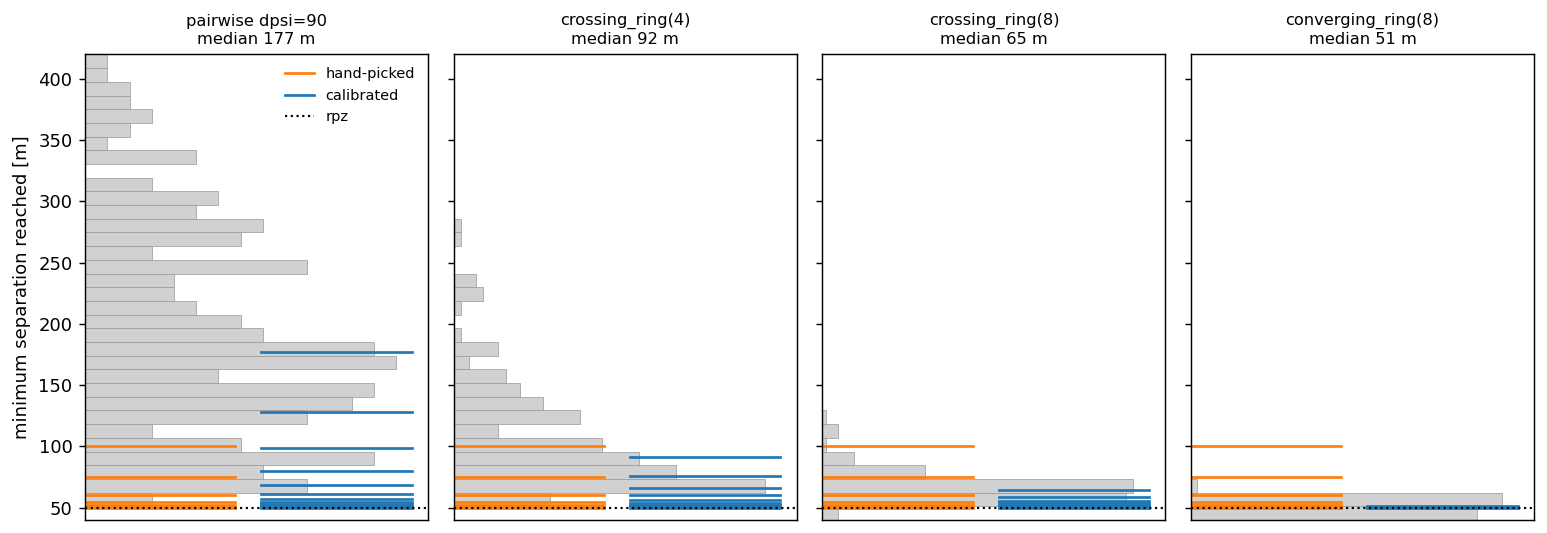

In [4]:
FIXED = [100.0, 75.0, 60.0, 55.0, 52.0, 51.0, 50.0]      # one ladder, selected by hand

# One y axis for every panel. The geometries are only comparable on a common scale, and the
# comparison is the point: the same CDR stack ends anywhere between 40 m and 400 m.
TOP = max(np.percentile(s, 99) for s in seps.values()) * 1.05

fig, axes = plt.subplots(1, 4, figsize=(12.0, 4.2), sharey=True)
for ax, (name, s) in zip(axes, seps.items()):
    ax.hist(s, bins=34, range=(RPZ * 0.8, TOP), orientation="horizontal",
            color="0.82", edgecolor="0.6", lw=0.4)
    xmax = ax.get_xlim()[1]
    for d in FIXED:                                   # left half of the panel
        ax.plot([0, xmax * 0.46], [d, d], color="tab:orange", lw=1.5)
    for d in ladder(s):                               # right half
        ax.plot([xmax * 0.54, xmax], [d, d], color="tab:blue", lw=1.5)
    ax.axhline(RPZ, color="k", lw=1.2, ls=":")
    ax.set_title(f"{name}\nmedian {np.median(s):.0f} m", fontsize=9)
    ax.set_xticks([])
ax.set_ylim(RPZ * 0.8, TOP)
axes[0].set_ylabel("minimum separation reached [m]")
axes[0].plot([], [], color="tab:orange", lw=1.5, label="hand-picked")
axes[0].plot([], [], color="tab:blue", lw=1.5, label="calibrated")
axes[0].plot([], [], color="k", lw=1.2, ls=":", label="rpz")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

Grey is where the encounters ended. Orange is the hand-picked ladder, blue the calibrated one.

Every panel uses the same y axis, thus you can compare the geometries directly. That comparison is
the finding. A pairwise encounter fills the full height of the figure, and the hand-picked ladder
stops at 100 m — it has no shells where most particles start. A converging ring is a thin band at
the bottom, and two of the hand-picked shells are above all of it, thus they do no work.

## 3. The trap: do not fix the number of shells

It is natural to select a number of shells — seven, for example — and use it everywhere. That
passes where the span is small and fails where the span is wide, and it always fails in the same
place.

The next cell needs no simulation. It is arithmetic on the two ladders.

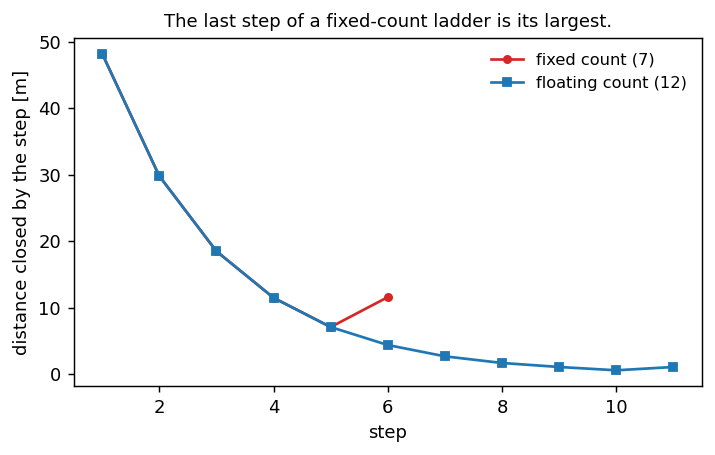

fixed count : [176.7, 128.5, 98.7, 80.2, 68.7, 61.6, 50.0]
   last step 11.6 m, after a step of 7.1 m
floating    : [176.7, 128.5, 98.7, 80.2, 68.7, 61.6, 57.2, 54.5, 52.8, 51.7, 51.1, 50.0]
   last step 1.1 m


In [5]:
wide = seps["pairwise dpsi=90"]
fixed_count = ladder(wide, fixed_levels=7)
floating = ladder(wide)

fig, ax = plt.subplots(figsize=(5.6, 3.6))
pair = ((fixed_count, "tab:red", f"fixed count ({len(fixed_count)})", "o"),
        (floating, "tab:blue", f"floating count ({len(floating)})", "s"))
for lad, colour, label, marker in pair:
    steps = [lad[k] - lad[k + 1] for k in range(len(lad) - 1)]
    ax.plot(range(1, len(steps) + 1), steps, marker=marker, ms=4, lw=1.5,
            color=colour, label=label)
ax.set_xlabel("step")
ax.set_ylabel("distance closed by the step [m]")
ax.set_title("The last step of a fixed-count ladder is its largest.", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"fixed count : {fixed_count}")
print(f"   last step {fixed_count[-2] - fixed_count[-1]:.1f} m, "
      f"after a step of {fixed_count[-3] - fixed_count[-2]:.1f} m")
print(f"floating    : {floating}")
print(f"   last step {floating[-2] - floating[-1]:.1f} m")

Six terms of the formula over this span put the sixth shell at about 62 m. The ladder then goes
from 62 m to 50 m in one step. That step is larger than the step before it, and it is at the end,
where the cloud is most thin.

Now fly both ladders and look at the survival of each shell.

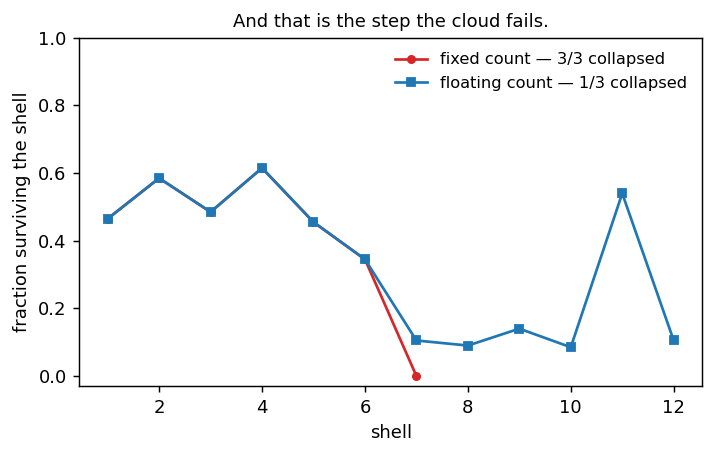

fixed count      P(LoS) = 0.000e+00   collapsed 3/3
floating count   P(LoS) = 8.454e-06   collapsed 1/3


In [6]:
runs = {"fixed count": split(GEOMETRIES["pairwise dpsi=90"], fixed_count),
        "floating count": split(GEOMETRIES["pairwise dpsi=90"], floating)}

fig, ax = plt.subplots(figsize=(5.6, 3.6))
for (label, cell), colour, marker in zip(runs.items(), ("tab:red", "tab:blue"), ("o", "s")):
    s = cell.reps[0].survival
    ax.plot(range(1, len(s) + 1), s, marker=marker, ms=4, lw=1.5, color=colour,
            label=f"{label} — {cell.n_collapsed}/{REPS} collapsed")
ax.set_ylim(-0.03, 1.0)
ax.set_xlabel("shell")
ax.set_ylabel("fraction surviving the shell")
ax.set_title("And that is the step the cloud fails.", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

for label, cell in runs.items():
    print(f"{label:16} P(LoS) = {cell.p_los_run:.3e}   collapsed {cell.n_collapsed}/{REPS}")

The two ladders are the same until the step where they differ. Then the fixed-count ladder loses
its whole cloud. A collapsed replication reports `P = 0`, which is not a small probability but an
absent measurement.

**Fix the ratio and let the number of shells follow the span.** Then every step is the same
relative size, including the last.

## 4. What a calibrated ladder gives: no shell is wasted

A level that almost every particle crosses does no work. A level that almost none cross is where
the variance comes from, and where a collapse starts. A calibrated ladder keeps every level between
those two conditions.

Run both ladders on all four geometries. Every panel shares one y axis, because the whole claim
is about where the levels sit between the two red bands.

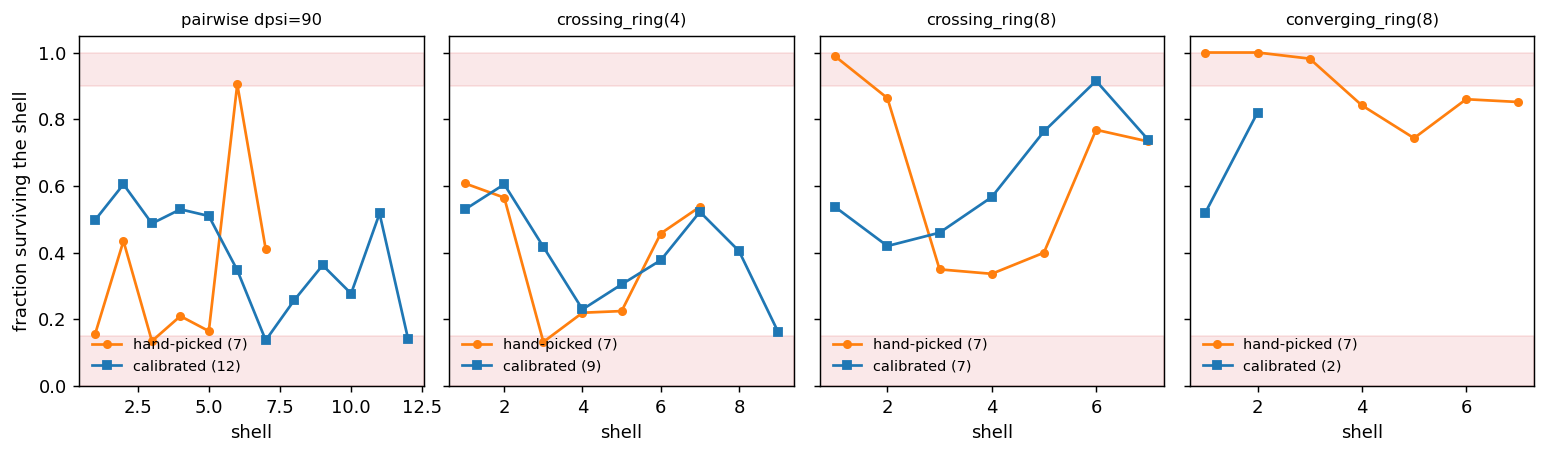

In [7]:
def survival_of(cell):
    """Mean survival per shell over the replications that finished the ladder.

    A collapsed replication stops early, so its `survival` is shorter. Averaging only the
    complete ones keeps the curve on one ladder; the collapses are reported separately.
    """
    whole = [r.survival for r in cell.reps if r.collapsed_at is None]
    return np.mean(whole or [cell.reps[0].survival], axis=0)


runs = {name: {"hand-picked": split(sc, FIXED),
               "calibrated": split(sc, ladder(seps[name]))}
        for name, sc in GEOMETRIES.items()}

fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.6), sharey=True)
for ax, (name, pair) in zip(axes, runs.items(), strict=True):
    ax.axhspan(0.9, 1.0, color="tab:red", alpha=0.10)     # above: the shell does no work
    ax.axhspan(0.0, 0.15, color="tab:red", alpha=0.10)    # below: the shell is too thin
    for (label, cell), colour, marker in zip(pair.items(), ("tab:orange", "tab:blue"), ("o", "s"),
                                             strict=True):
        s = survival_of(cell)
        ax.plot(range(1, len(s) + 1), s, marker=marker, ms=4, lw=1.5, color=colour,
                label=f"{label} ({len(s)})")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("shell")
    ax.set_title(name, fontsize=9)
    ax.legend(frameon=False, fontsize=8, loc="lower left")
axes[0].set_ylabel("fraction surviving the shell")
fig.tight_layout()
plt.show()

In [8]:
print(f"{'geometry':20} {'shells':>14}   {'P(LoS) hand':>12} {'P(LoS) cal':>12}   collapsed")
for name, pair in runs.items():
    hand, cal = pair["hand-picked"], pair["calibrated"]
    n_hand, n_cal = len(FIXED), len(cal.reps[0].levels)
    coll = f"{sum(r.collapsed_at is not None for r in hand.reps)}/{REPS} vs " \
           f"{sum(r.collapsed_at is not None for r in cal.reps)}/{REPS}"
    print(f"{name:20} {n_hand:>6} -> {n_cal:<4}   "
          f"{hand.p_los_run:>12.3e} {cal.p_los_run:>12.3e}   {coll}")

geometry                     shells    P(LoS) hand   P(LoS) cal   collapsed
pairwise dpsi=90          7 -> 12        3.901e-05    8.454e-06   2/3 vs 1/3
crossing_ring(4)          7 -> 9         3.946e-04    1.264e-04   1/3 vs 1/3
crossing_ring(8)          7 -> 7         2.348e-02    3.157e-02   0/3 vs 0/3
converging_ring(8)        7 -> 2         4.485e-01    4.259e-01   0/3 vs 0/3


Read the panels from right to left. The converging ring is the clearest case: the hand-picked
ladder keeps its first three shells at 1.00, 1.00 and 0.98, thus they do no work, and the
calibrated ladder replaces all seven shells with two. Go left and the span becomes larger, and the
hand-picked ladder makes the opposite error — on the pairwise encounter it puts levels at 0.15,
0.21 and 0.16, in the lower band, and then one at 0.90. The calibrated curve is more flat than the
hand-picked one on every geometry. That is the result.

**It is more flat, but it is not inside the bands.** On the two wide geometries the calibrated
ladder also touches the lower band. That is the number of particles and not the shape of the
ladder: 200 particles cannot hold a cloud through twelve shells. The campaign uses 2000.

**The two estimates do not agree here, and the collapse counts tell you why.** A collapsed
replication contributes exactly zero to the mean. On the pairwise encounter 2 of 3 and 1 of 3
replications collapsed, thus both numbers are mostly a count of collapses and you must not compare
them. The two rings, where nothing collapsed, agree within a factor of 1.4. Compare estimates only
on rows with no collapse — and the row always reports the count, thus you can see it.

## 5. What calibration does not give

Calibration does **not** make the estimator more reliable. On these geometries a ladder selected by
hand collapses no more often than a calibrated one — sometimes less.

The reason is that all four geometries end between about 50 m and 300 m, and the hand-picked
ladder `[100 ... 50]` goes through that band. It was selected for a pairwise encounter and it
also operates for these rings, by chance. A geometry outside the band needs a different ladder,
and a person must select it.

So the correct reason to calibrate is **automation and efficiency**:

- You do not tune a ladder by hand when you add a geometry.
- No level is wasted, thus the same answer costs less.

The measurements behind this, at larger particle counts, are in
`vault/observations/ips-ladder-calibration.md`.

## Summary

| | rule |
|---|---|
| First shell | the pilot median — about half the cloud crosses it |
| Spacing | a constant ratio, thus each level survives at about the same rate |
| Number of shells | let it follow the span; do not fix it |
| Median inside `rpz` | start above the boundary, at the 90th percentile |
| Pilot size | 200 to 300 encounters — it must only find the upper range |

A collapsed replication is reported and is not hidden. If you see one, add particles first: a
collapse is more often too few particles than a bad ladder.